# Example: Hierarchical clustering on the Zheng dataset

This notebook shows a structured GraphHDBSCAN workflow on the Zheng dataset in order to reproduce condensed tree that is reported in GraphHDBSCAN* paper.

We go through:
1. package installation
2. imports and setup
3. data loading / preparation
4. model construction and fitting
5. condensed tree visualization
6. optional interactive exploration

The static condensed tree is kept in the notebook because it renders reliably in the built documentation.


## Installation

These commands are only needed when you run the notebook in a fresh environment.

Install required package(s):

```bash
!pip install git+https://github.com/Campello-Lab/GraphHDBSCAN.git
```

## Build and fit the model

Configure the GraphHDBSCAN model, fit it on the dataset, and inspect the resulting clustering state.

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

## Load and prepare the dataset

Load the Zheng dataset and prepare the matrix or AnnData object used by the clustering pipeline.

In [3]:
import yaml
import scanpy as sc
from sklearn.neighbors import NearestNeighbors as NN
from sklearn.metrics import pairwise_distances
# Load the YAML configuration file
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Zheng_config = config["DATASETS"]["Zheng"]
expected_cell_label = Zheng_config["cell_labels"]

adata = sc.read_h5ad("/content/Zheng.h5ad")
# Print available columns in adata.obs
available_columns = list(adata.obs.columns)
print("Available columns in adata.obs:", available_columns)

cell_label_key = expected_cell_label

# Extract the count matrix and cell labels
count_matrix = adata.X  # Cells as rows and genes as columns
true_labels = adata.obs[cell_label_key]

Available columns in adata.obs: ['label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'norm_factor']


In [4]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,10),
    sim_graph_method="jaccard_phenograph",
    n_neighbors=7,
    no_noise=True,
    metric="euclidean",
    min_cluster_size=60
)


In [5]:
g.fit(adata.X)

Using neighbor information from provided graph, rather than computing neighbors directly
Jaccard graph constructed in 0.49872446060180664 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.679931640625 seconds
[CORE-SG] (precomputed) CORE-SG graph has 1847277 edges
[CORE-SG] m= 2: MST+tree+labels in 1.0235s
[CORE-SG] m= 3: MST+tree+labels in 0.8560s
[CORE-SG] m= 4: MST+tree+labels in 0.8922s
[CORE-SG] m= 5: MST+tree+labels in 0.8917s
[CORE-SG] m= 6: MST+tree+labels in 0.8946s
[CORE-SG] m= 7: MST+tree+labels in 0.8869s
[CORE-SG] m= 8: MST+tree+labels in 0.9154s
[CORE-SG] m= 9: MST+tree+labels in 0.8035s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5, 6, 7, 8, 9], metric='euclidean', eps=1e-12, min_cluster_size=60, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

## Visualize the hierarchy

Start with a static condensed tree for reliable rendering in the documentation, then show the interactive widget for live notebook use.

<Axes: title={'center': 'Condensed Tree for m = 7'}, ylabel='$\\lambda$ value'>

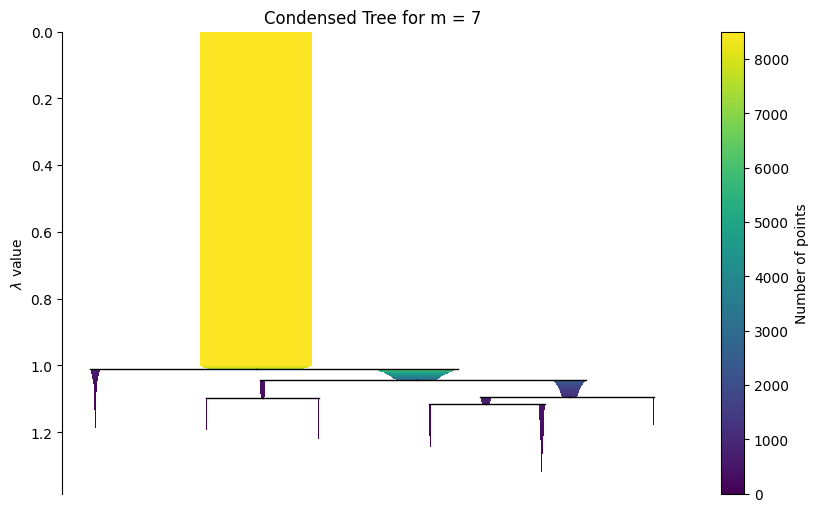

In [9]:
g.plot_condensed_tree(7)

> The widget below works best in a live Jupyter session. In rendered HTML documentation, widget interactivity may be limited.

In [10]:
g.interactive_condensed_tree()


SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5, 6…

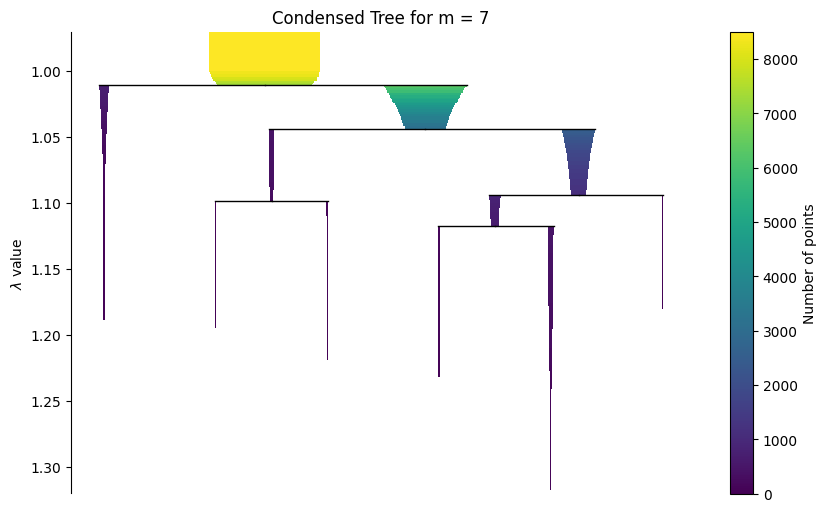

In [11]:
import matplotlib.pyplot as plt

ax = g.plot_condensed_tree(7)
ax.set_ylim(1.32, 0.97)
plt.show()